Decision Tree Classification on Heart Disease Dataset
1. Objective

The objective of this assignment is to apply the Decision Tree Classification algorithm on the Heart Disease dataset to predict whether a person has heart disease or not. The assignment involves performing exploratory data analysis (EDA), preprocessing the dataset, training the model, tuning hyperparameters, evaluating model performance, and interpreting the results.

Decision Trees are widely used in healthcare prediction systems because they are interpretable and easy to understand, making them useful for identifying important risk factors for diseases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



2. Data Preparation

In [2]:
import pandas as pd

df = pd.read_excel("/content/heart_disease.xlsx", sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
#3. Exploratory Data Analysis (EDA
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [5]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [6]:
df = df.apply(pd.to_numeric, errors='coerce')

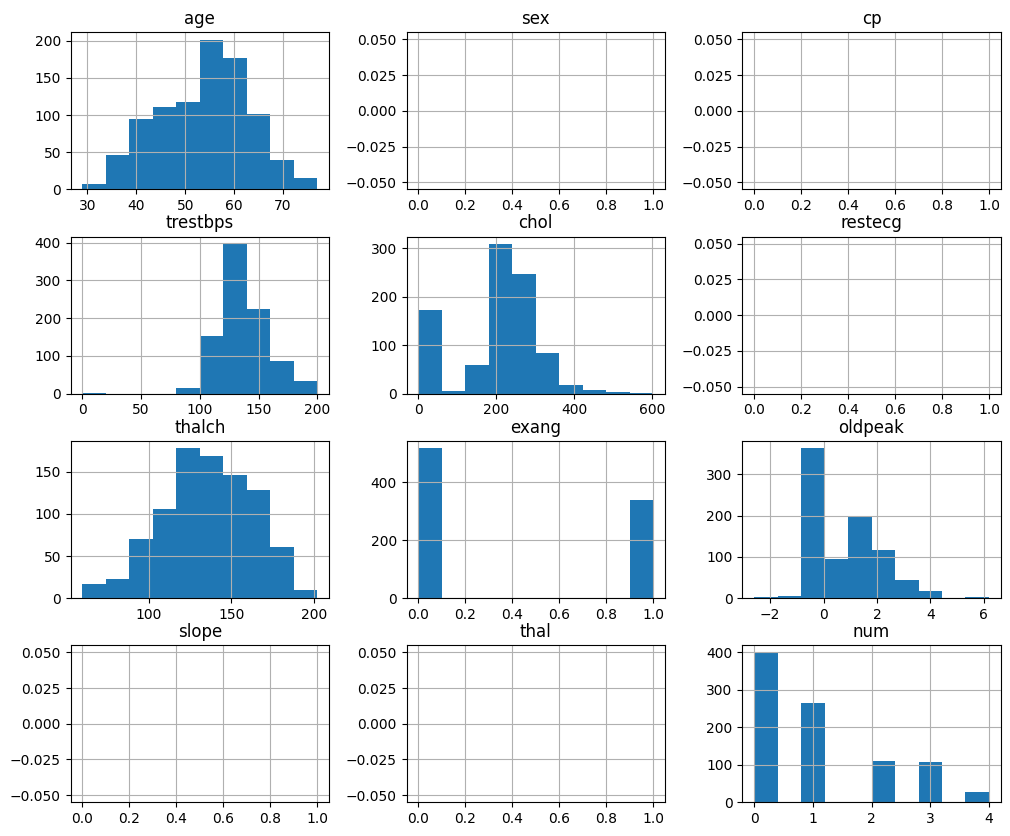

In [7]:
df.hist(figsize=(12,10))
plt.show()

In [8]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')


In [9]:
df.columns = df.columns.str.strip()

In [10]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')


In [11]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,NaN,NaN,145,233,True,NaN,150,0.0,2.3,NaN,NaN,0
1,41,NaN,NaN,135,203,False,NaN,132,0.0,0.0,NaN,NaN,0
2,57,NaN,NaN,140,192,False,NaN,148,0.0,0.4,NaN,NaN,0
3,52,NaN,NaN,118,186,False,NaN,190,0.0,0.0,NaN,NaN,0
4,57,NaN,NaN,110,201,False,NaN,126,1.0,1.5,NaN,NaN,0


In [12]:
df.shape

(908, 13)

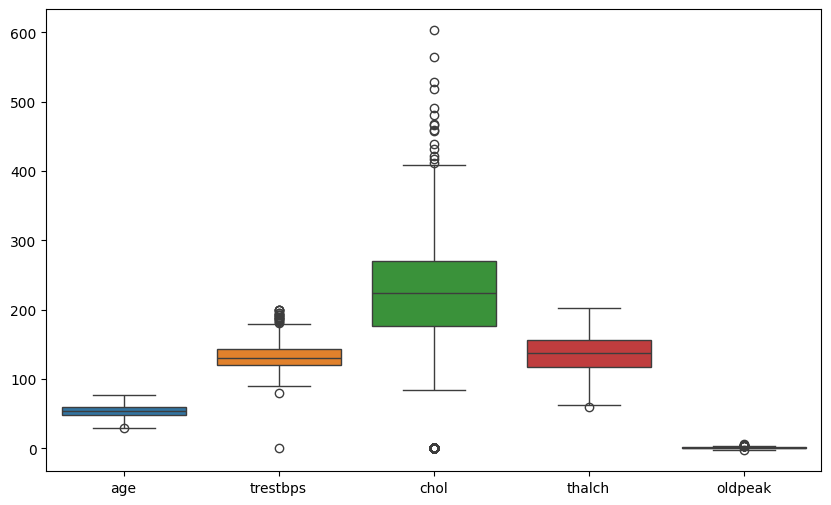

In [13]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age','trestbps','chol','thalch','oldpeak']])
plt.show()
plt.show()

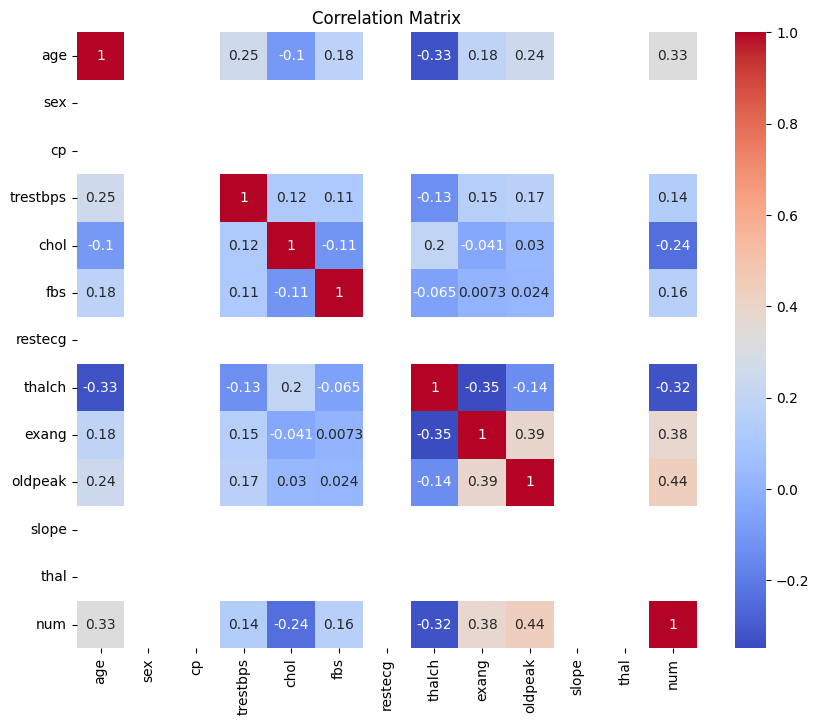

In [14]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [15]:
#3. Feature Engineering
df = df_encoded

In [16]:
X = df.drop('num', axis=1)
y = df['num']

Train Test Split (80-20)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

5. Decision Tree Classification

In [18]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

6. Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.46153846153846156
              precision    recall  f1-score   support

           0       0.67      0.63      0.65        89
           1       0.33      0.42      0.37        48
           2       0.19      0.18      0.19        22
           3       0.29      0.24      0.26        17
           4       0.00      0.00      0.00         6

    accuracy                           0.46       182
   macro avg       0.30      0.29      0.29       182
weighted avg       0.47      0.46      0.46       182



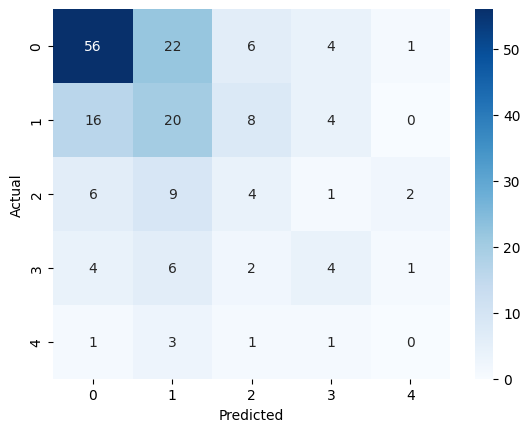

In [20]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7. Hyperparameter Tuning

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


8. Visualize Decision Tree


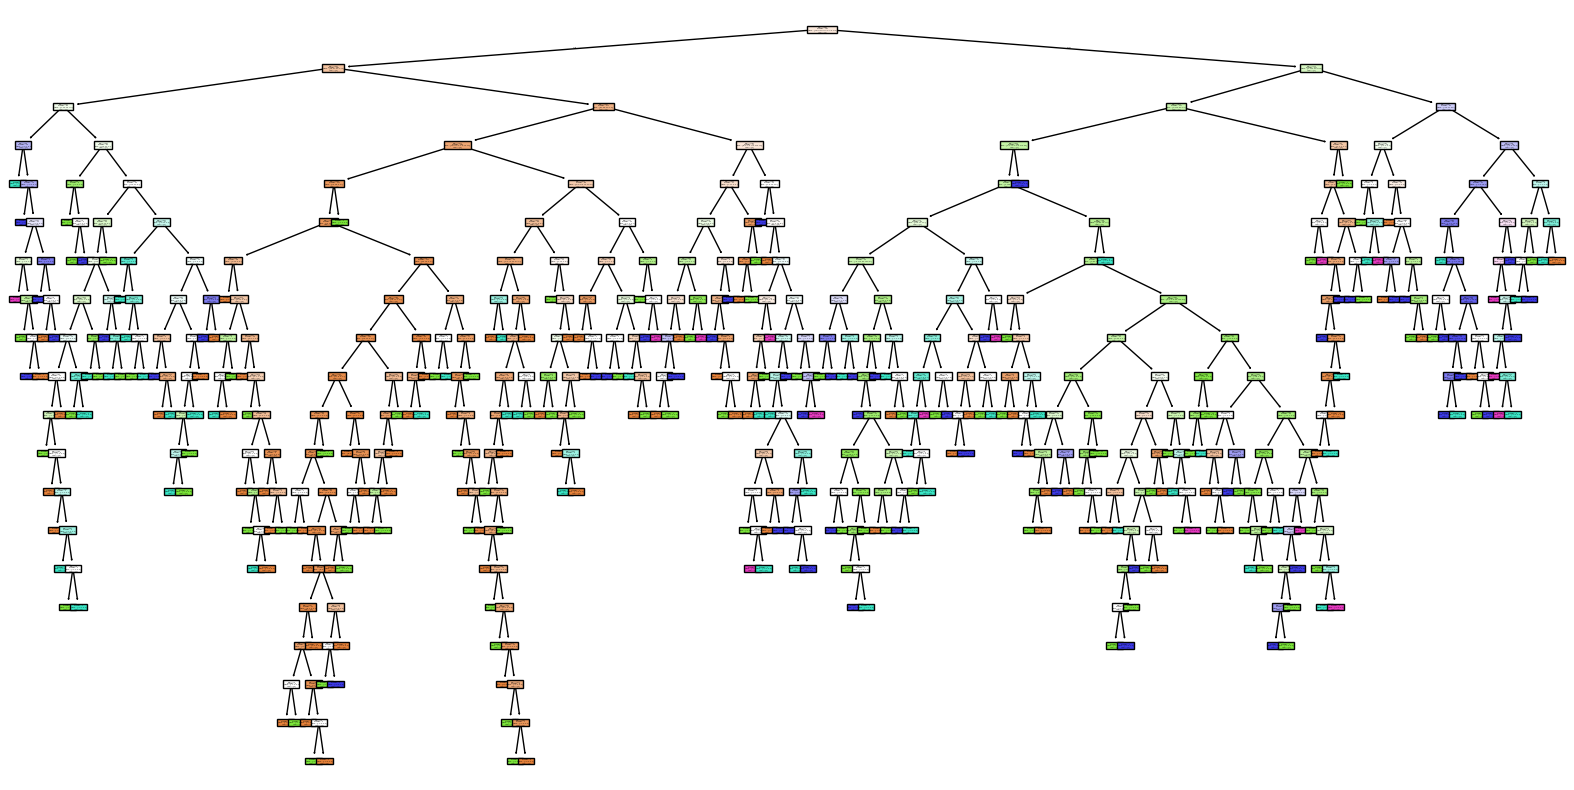

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(model,
          feature_names=X.columns,
          class_names=True,
          filled=True)

plt.show()

Interview Questions
1. What are common hyperparameters of Decision Tree?

Common hyperparameters include:

Hyperparameter	Description
max_depth	Maximum : depth of the tree. Prevents overfitting
min_samples_split:	Minimum samples required to split a node
min_samples_leaf:	Minimum samples required at leaf node
criterion:	Function to measure split quality (gini or entropy)
max_features:	Number of features considered for splitting

2. Difference Between Label Encoding and One-Hot Encoding
**Label Encoding	**                        
Converts categories into numbers        
Example: Male=0, Female=1	                
Used when categories have order	         
May introduce wrong relationships

---
 **One-Hot Encoding**
Creates binary columns
Male=[1,0], Female=[0,1]
Used when categories have no  order
More accurate for ML models